# Building Blocks of Neural Networks

## Activation Functions

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

block_plot = False
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)

In [10]:
def plot_activation(x, y, y_label, title):
    plt.figure
    plt.plot(x, y, color="green")
    plt.xlabel("X")
    plt.ylabel(y_label)
    plt.title(title)
    plt.show(block=block_plot)
    plt.close()

### Sigmoid Function

$$
y' = \sigma(x) = \frac{1}{1 + e^{-x}}
$$

It is **best suited for binary classification**. As such, we can infer a few things from the following:

 - If  $sigmoid(x) > 0.5$ then input belongs to the positive class or class 1
 - If  $sigmoid(x) < 0.5$ then input belongs to the positive class or class 0

The sigmoid output `y'` may be thought of as the probability that the data point belongs to class 1. 
So, the probability that it belongs to class 0 will be `1−y'`.

It is mostly used in the **final layer of a neural network**.

One of the biggest disadvantages of the Sigmoid activation is the **vanishing gradient** problem.

Observations from the sigmoid plot:

- $sigmoid(0) = 0.5$
- $sigmoid(x) > 0.5 \space ∀ \space y > 0$
- $sigmoid(x) < 0.5 \space ∀ \space y < 0$

- Sigmoid is not **zero-centered**.  


#### Zero-Centered
`Sigmoid` is not considered as zero-centered because of its output range, which lies between 0. and 1, while `tanh` is true zero-centered.

When the outputs of the sigmoid function are fed into the next layer as inputs in a neural network, they can cause the inputs to the neurons in the subsequent layers to all be positive or negative, depending on the weights and biases applied.

However, while the sigmoid's outputs are always positive, the direction of the gradient updates for the weights during backpropagation can be either positive or negative, depending on the gradient of the loss function.

In neural networks, the gradient of the loss function with respect to each weight in the network involves the product of the gradient of the activation function at that neuron and the gradient of the loss with respect to the output of that neuron (chain rule in backpropagation).
The key point here is that even though sigmoid outputs are not zero-centered and always positive, the gradient of the loss with respect to these outputs could be either positive or negative, influencing the direction of the weight updates.

The non-zero-centered nature of sigmoid outputs affects gradient updates by making the optimization process less efficient. When activations are not zero-centered (i.e., predominantly positive as with sigmoid), it can lead to situations where gradient updates for weights are consistently biased in a certain direction, potentially leading to inefficient training dynamics (like slower convergence), but it does not strictly cause all updates to be in the same direction.

In [3]:
def sigmoid(x):
    return 1 / (1 + tf.math.exp(-x))

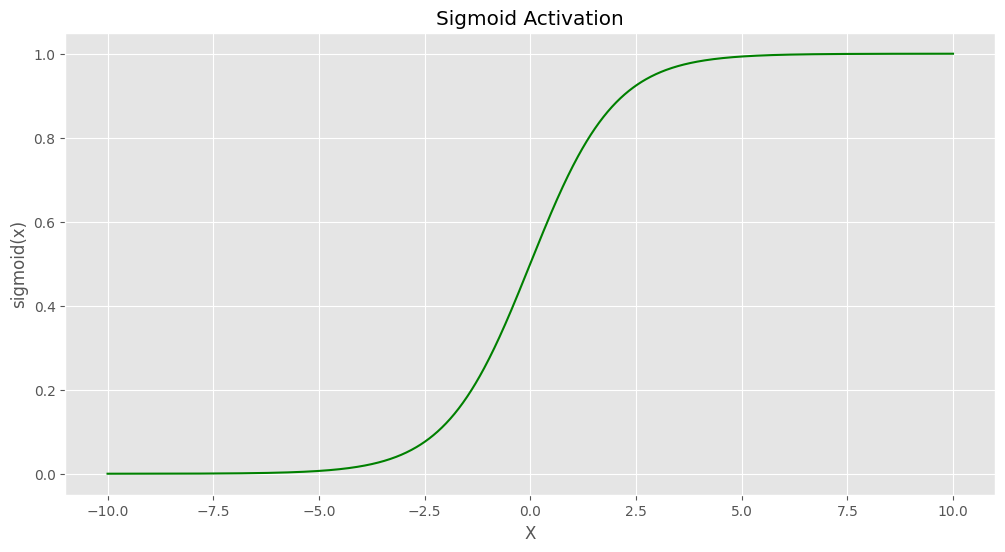

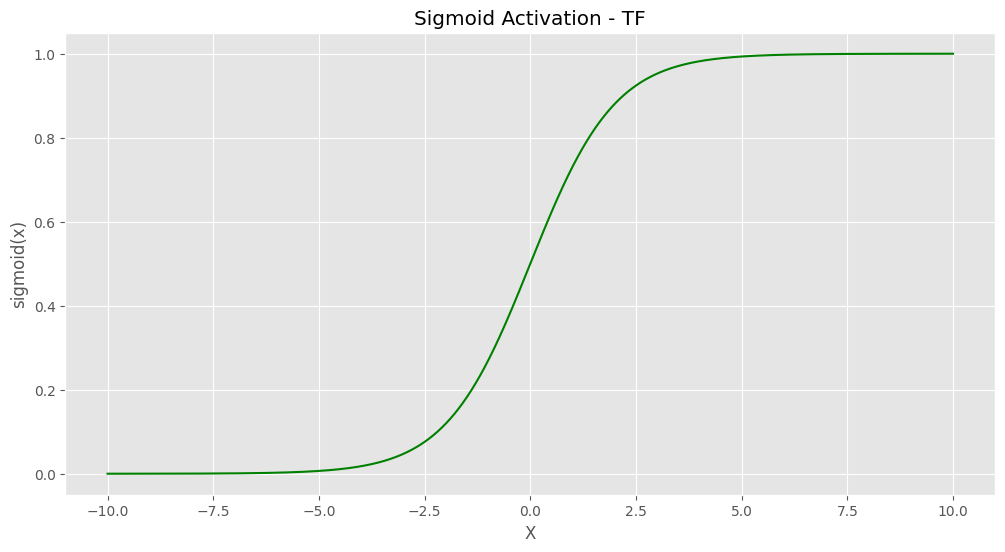

In [14]:
# Plot the sigmoid activation function
x = tf.linspace(-10, 10, 1000)
y = sigmoid(x)

plot_activation(x, y, "sigmoid(x)", "Sigmoid Activation")

y_tf = tf.nn.sigmoid(x)
plot_activation(x, y, "sigmoid(x)", "Sigmoid Activation - TF")

### Tanh (Hyperbolic Tangent) Function

- It is the shifted and scaled version of the Sigmoid logistic function
- Output range is from -1 to 1
- It is zero-centered

$$
tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

In [12]:
def tanh(x):
    return (tf.math.exp(x) - tf.math.exp(-x)) / (tf.math.exp(x) + tf.math.exp(-x))

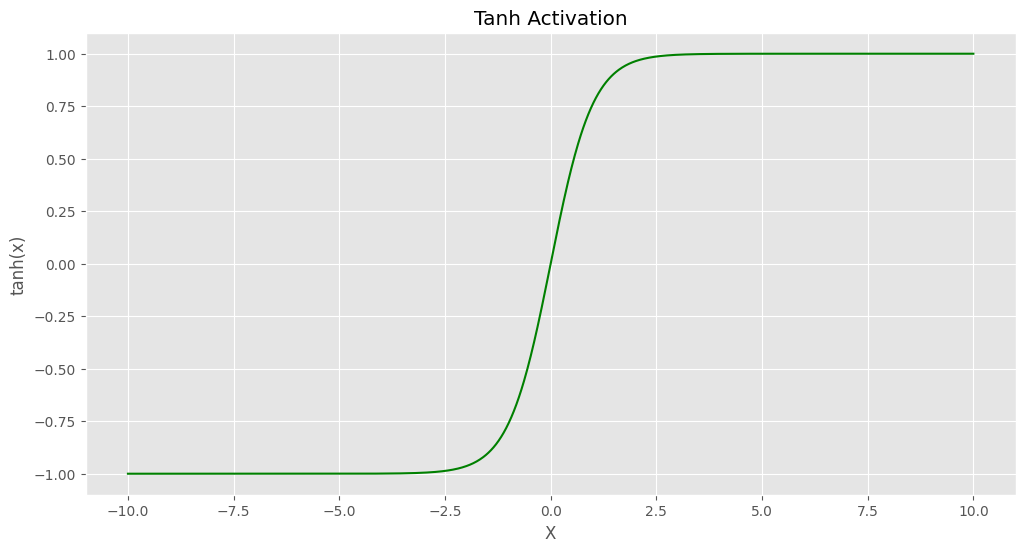

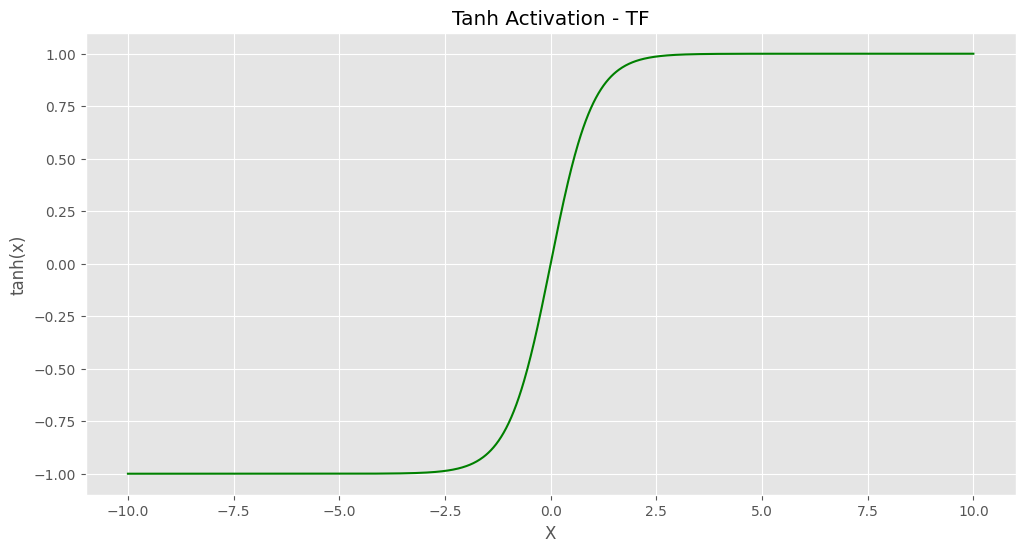

In [13]:
y = tanh(x)
plot_activation(x, y, "tanh(x)", "Tanh Activation")

y_tf = tf.nn.tanh(x)
plot_activation(x, y_tf, "tanh(x)", "Tanh Activation - TF")

### ReLU (Rectified Linear Unit) Function

$$
ReLU(x) = max(x,0) 
$$

- Simple and faster to calculate.
- Improves the accuracy of all domains in Deep learning.
- Fixes the vanishing gradient.
- Useful in Deep Neural Network.
- Represents 'True Zero'.

Disadvantages:
- Exploding gradient
- For values below 0, the function return 0, i.e., there isn't any non-linearity in this part of the function.

In [15]:
def relu(x):
    return tf.maximum(0, x)

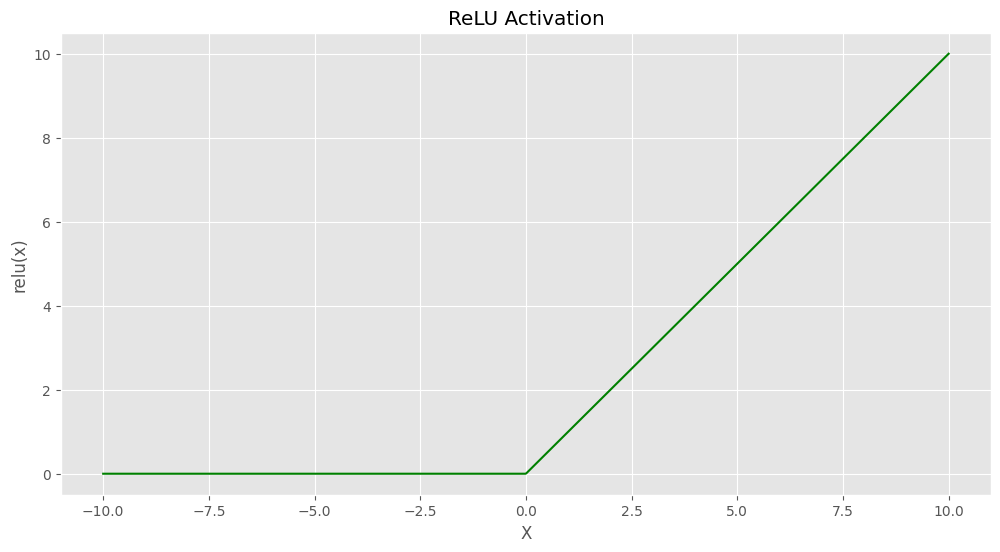

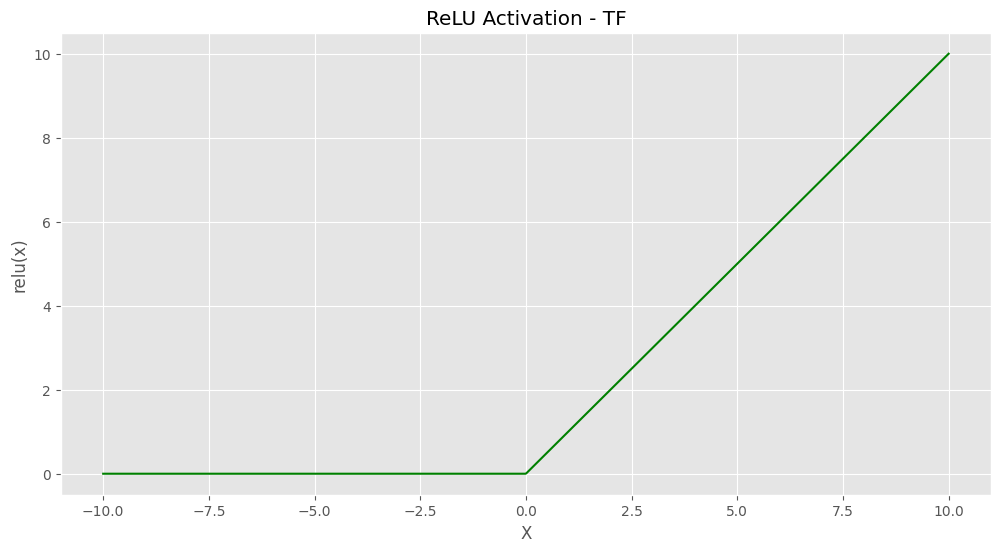

In [16]:
y = relu(x)
plot_activation(x, y, "relu(x)", "ReLU Activation")

y = tf.nn.relu(x)
plot_activation(x, y, "relu(x)", "ReLU Activation - TF")

### ELU (Exponential Linear Unit) Function

$$
ELU(x) = \left\{
    \begin{array}{c l}
    \alpha(e^x -1), \quad \textrm{if } x < 0 \\
    x, \quad \quad \quad \textrm{otherwise}
    \end{array}
\right.
$$

- Applies a $\alpha$ contant which adds non-linearity when the `x < 0`.
- ELU is less likely to have an exploding gradient problem as sometimes maybe the case with ReLU.
- ELU does not suffer from the dying relu issue as ReLU does. 

Disadvantages:
- slower to compute because it also applies non-linearity to negative inputs

In [19]:
def elu(x):
    return [i if i > 0 else 1.0 * (tf.math.exp(i) - 1) for i in x]

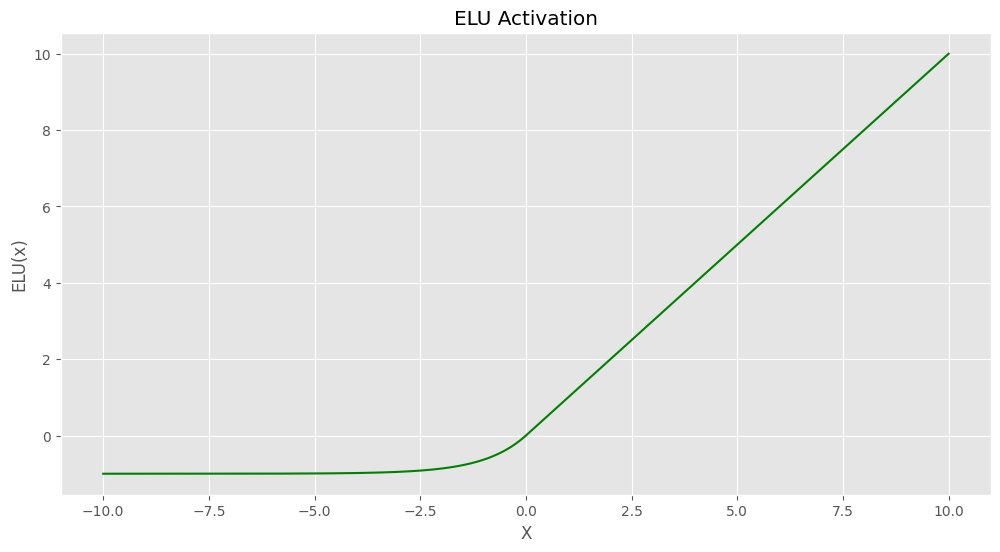

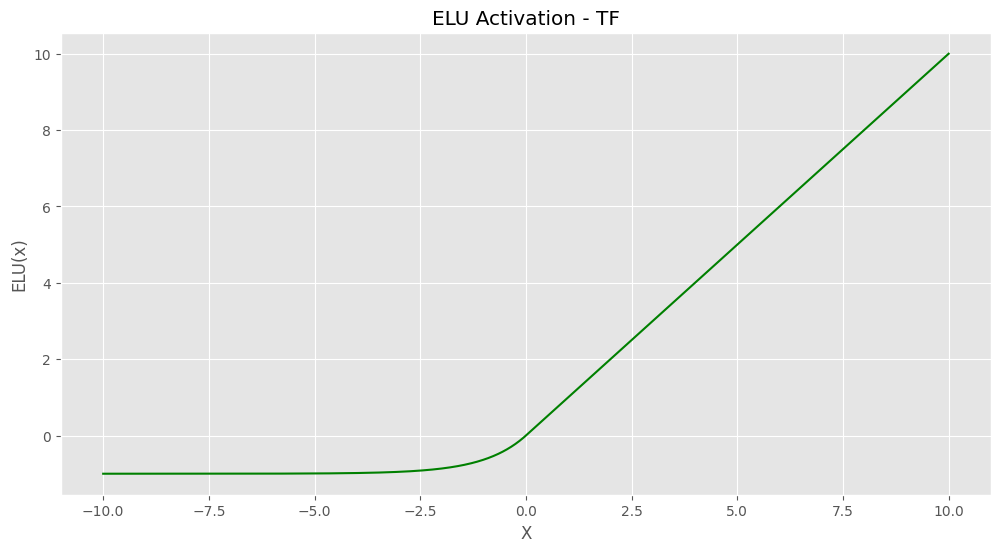

In [20]:
y = elu(x)
plot_activation(x, y, "ELU(x)", "ELU Activation")

y = tf.nn.elu(x)
plot_activation(x, y, "ELU(x)", "ELU Activation - TF")

## Time Comparisions between Activation Functions 

In [ ]:
import time

N_RUNS = 100
activationTimes = []

SIGMOID = "sigmoid"
TANH = "tanh"
RELU = "relu"
ELU = "elu"
LEAKY_RELU = "leaky"

In [30]:
def getActivationFunction(activationFuncName: str):
    match activationFuncName:
        case "sigmoid":
            return tf.nn.sigmoid
        case "tanh":
            return tf.nn.tanh
        case "relu":
            return tf.nn.relu
        case "elu":
            return tf.nn.elu
        case "leaky":
            return tf.nn.leaky_relu


def executeRuns(activationFuncName: str):
    activationFunc = getActivationFunction(activationFuncName)

    run_times = []
    for i in range(N_RUNS):
        start = time.time()
        x = tf.linspace(-10, 10, 1000)
        y = activationFunc(x)
        run_time = time.time() - start
        run_times.append(run_time)

    plot_activation(x, y, activationFuncName, activationFuncName)
    activationTimes.append(sum(run_times) / N_RUNS)

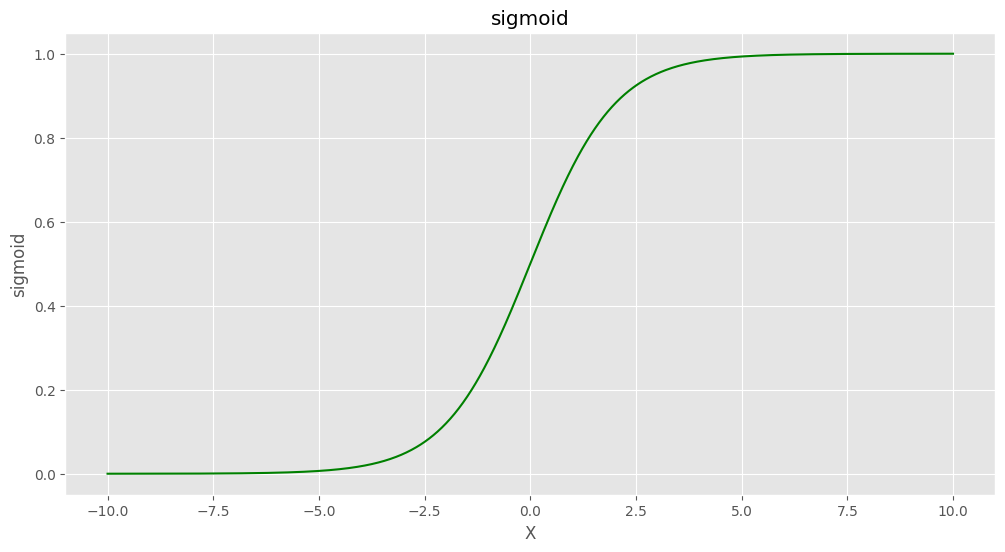

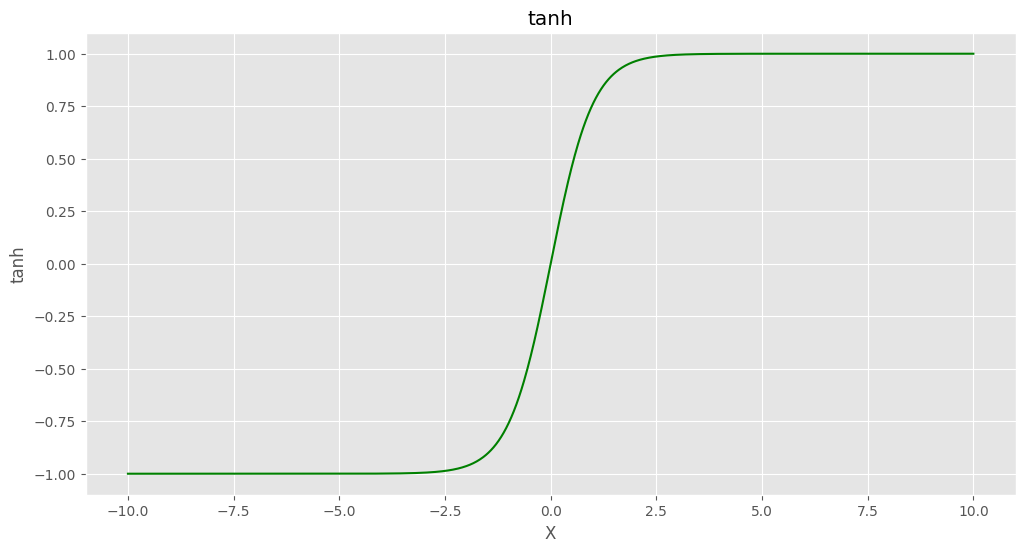

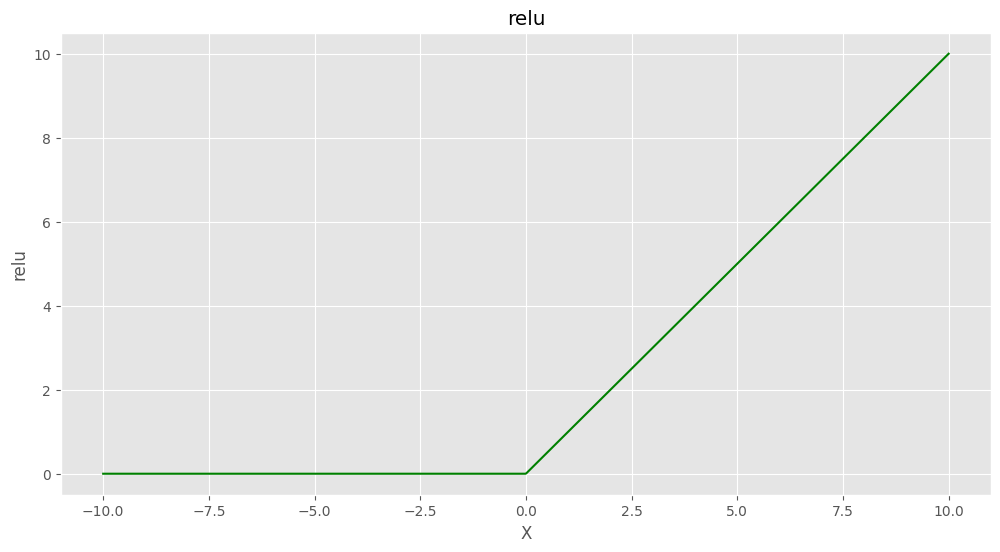

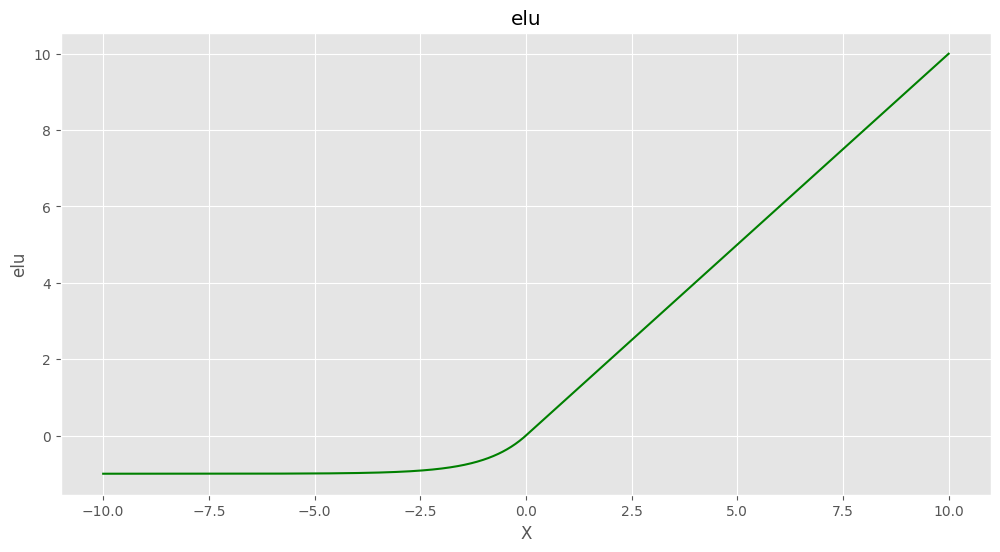

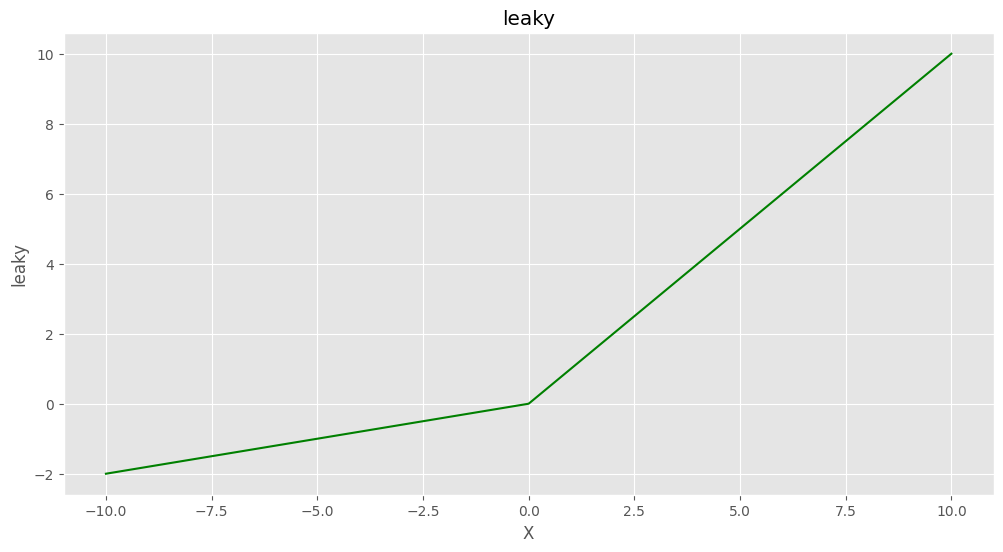

[0.0013408851623535156, 0.0013091516494750976, 0.0013067483901977538, 0.0013580369949340821, 0.0013583970069885253]


In [31]:
activationTimes = []
executeRuns(SIGMOID)
executeRuns(TANH)
executeRuns(RELU)
executeRuns(ELU)
executeRuns(LEAKY_RELU)

print(activationTimes)